# Week 6 – Bivariate Analysis, part 2
## Dataset: SHED Public Use Data 2025
*Survey of Household Economics and Decisionmaking — Federal Reserve Board*

# 1. Lesson: no lesson this week

# 2. Weekly Graph Question

Suppose you wanted to show the nitrate and phosphate level in a water sample. What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs? How would you adjust the graphs shown to improve the presentation?

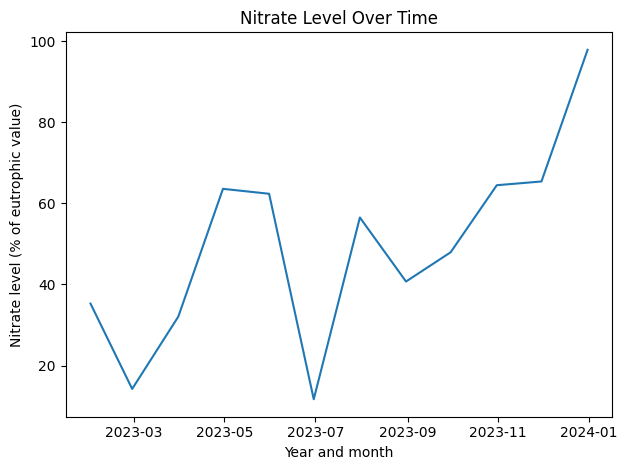

In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size=numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x=datearray, y=time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")
plt.title("Nitrate Level Over Time")
plt.tight_layout()
plt.show()

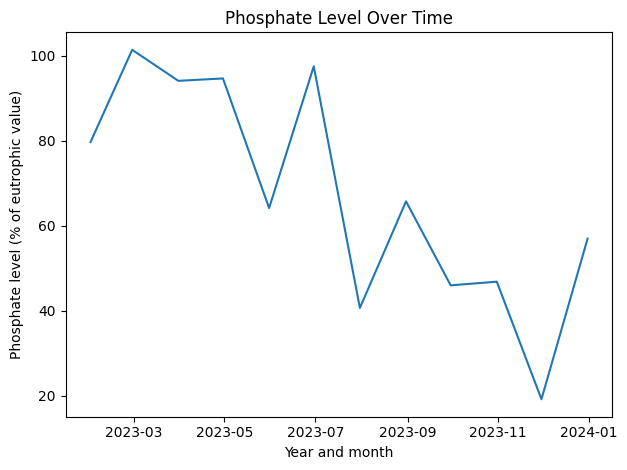

In [6]:
np.random.seed(1)
time_series_2 = 100 * (1 - (np.random.normal(size=numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x=datearray, y=time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")
plt.title("Phosphate Level Over Time")
plt.tight_layout()
plt.show()

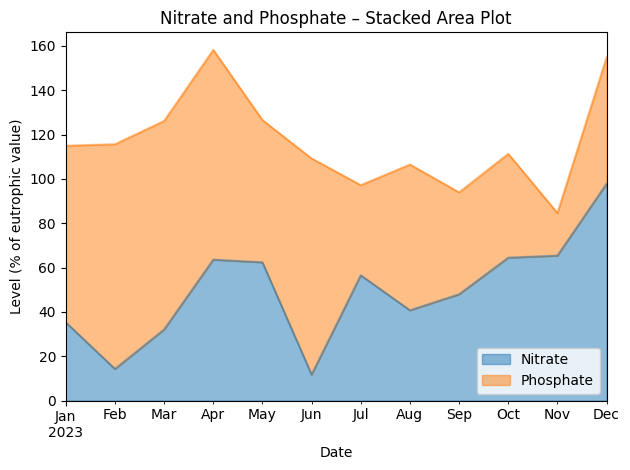

In [7]:
df = pd.DataFrame({'Nitrate': time_series, 'Phosphate': time_series_2}, index=datearray)
df.plot.area(alpha=0.5)
plt.title("Nitrate and Phosphate – Stacked Area Plot")
plt.xlabel("Date")
plt.ylabel("Level (% of eutrophic value)")
plt.tight_layout()
plt.show()

## Written Response: Area Plot vs. Two Separate Line Graphs

### Advantages of a stacked area plot
| Advantage | Explanation |
|---|---|
| Shows combined total | The top of the stacked area represents the sum of both nutrients at each time point |
| Single chart | Both series are visible simultaneously, saving space and enabling side-by-side comparison |
| Visual proportion | The relative band sizes show each series' share of the combined total |

### Disadvantages of a stacked area plot
| Disadvantage | Explanation |
|---|---|
| **Misleading for independent quantities** | Nitrate and phosphate are separate measurements — stacking implies they sum to something meaningful, which they do not |
| **Negative values break the metaphor** | When the first series goes negative, the stacking logic breaks and the chart becomes visually confusing |
| **Top series distorted** | The upper series is plotted relative to the top of the lower one, not from zero — actual values are unreadable |
| **Color overlap** | Alpha-blended overlap zones create mixed colors that are hard to identify |

### Recommended improvements
1. **Use a dual-series line plot** with two labeled lines on the same axes — correct representation for two independent time series.
2. Add a **horizontal reference line** at 100% (eutrophic threshold) on both series.
3. **Rotate x-axis labels** and format dates as `MMM YYYY`.
4. Remove the area fill — it conveys no information for independent measures.
5. Use distinct, clearly distinguishable colors and add a legend.

# 3. Working on Your Dataset

---
## Dataset: SHED Public Use Data 2025
*Federal Reserve — Survey of Household Economics and Decisionmaking*

**12,908 respondents × 816 columns.** For bivariate analysis we focus on the core demographic numeric variables:
`ppage` (age), `pphhsize` (household size), `ppkid017` (children <17), `ppt18ov` (adults 18+), and the derived size category `pphhsize5`.

### Analysis plan
- Compute the correlation matrix
- Visualize as a heatmap
- Draw scatterplots for the three most meaningful pairs
- Draw a pairplot of all four core variables
- Conclusions: redundancy, outliers, confounders

In [8]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load SHED dataset
shed = pd.read_csv("SHED_public_use_data_2025.csv",
                   low_memory=False)

# Select core demographic numeric columns for bivariate analysis
shed_cols = ['ppage', 'pphhsize', 'ppkid017', 'ppt18ov', 'pphhsize5']
corr_df = shed[shed_cols].dropna()
corr_matrix = corr_df.corr()

print(f"SHED shape: {shed.shape}")
print(f"Rows with all 5 columns complete: {len(corr_df):,}")
print(f"\nCorrelation matrix:")
print(corr_matrix.round(3))

SHED shape: (12908, 816)
Rows with all 5 columns complete: 12,908

Correlation matrix:
           ppage  pphhsize  ppkid017  ppt18ov  pphhsize5
ppage      1.000    -0.327    -0.301   -0.184     -0.340
pphhsize  -0.327     1.000     0.724    0.752      0.958
ppkid017  -0.301     0.724     1.000    0.089      0.674
ppt18ov   -0.184     0.752     0.089    1.000      0.739
pphhsize5 -0.340     0.958     0.674    0.739      1.000


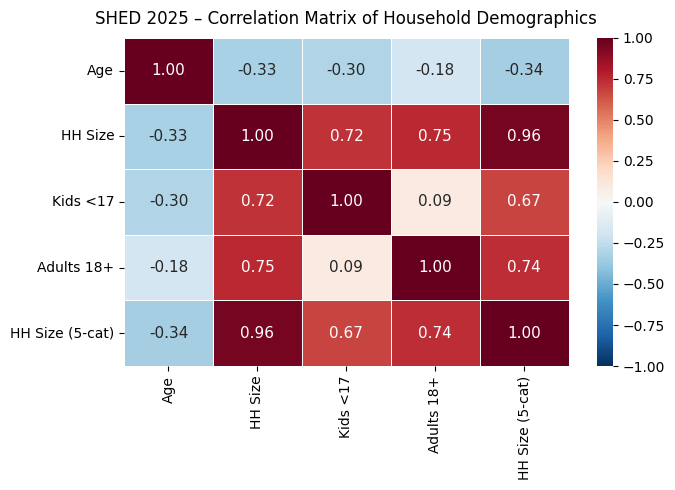

In [9]:
col_labels = {
    'ppage':     'Age',
    'pphhsize':  'HH Size',
    'ppkid017':  'Kids <17',
    'ppt18ov':   'Adults 18+',
    'pphhsize5': 'HH Size (5-cat)'
}

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix.rename(index=col_labels, columns=col_labels),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('SHED 2025 – Correlation Matrix of Household Demographics', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

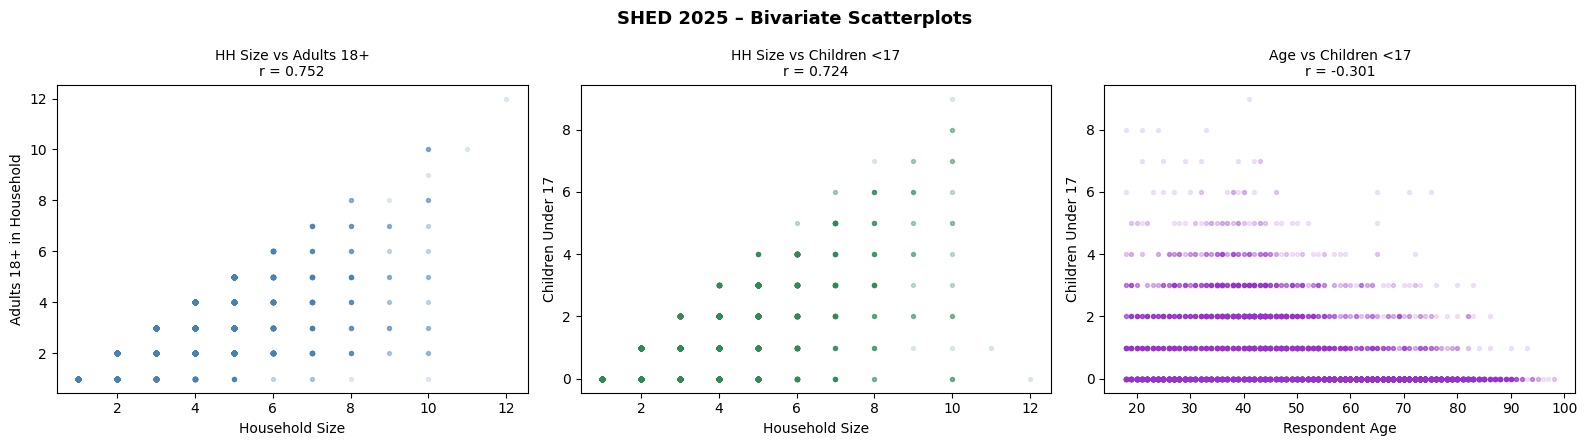

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Household size vs Adults 18+  (expected: strong positive)
axes[0].scatter(shed['pphhsize'], shed['ppt18ov'],
                alpha=0.15, s=8, color='steelblue')
axes[0].set_xlabel('Household Size')
axes[0].set_ylabel('Adults 18+ in Household')
r1 = shed[['pphhsize', 'ppt18ov']].corr().iloc[0, 1]
axes[0].set_title(f'HH Size vs Adults 18+\nr = {r1:.3f}', fontsize=10)

# 2. Household size vs Children under 17  (expected: positive)
axes[1].scatter(shed['pphhsize'], shed['ppkid017'],
                alpha=0.15, s=8, color='seagreen')
axes[1].set_xlabel('Household Size')
axes[1].set_ylabel('Children Under 17')
r2 = shed[['pphhsize', 'ppkid017']].corr().iloc[0, 1]
axes[1].set_title(f'HH Size vs Children <17\nr = {r2:.3f}', fontsize=10)

# 3. Age vs Children under 17  (expected: negative - older respondents have fewer kids at home)
axes[2].scatter(shed['ppage'], shed['ppkid017'],
                alpha=0.12, s=8, color='darkorchid')
axes[2].set_xlabel('Respondent Age')
axes[2].set_ylabel('Children Under 17')
r3 = shed[['ppage', 'ppkid017']].corr().iloc[0, 1]
axes[2].set_title(f'Age vs Children <17\nr = {r3:.3f}', fontsize=10)

plt.suptitle('SHED 2025 – Bivariate Scatterplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

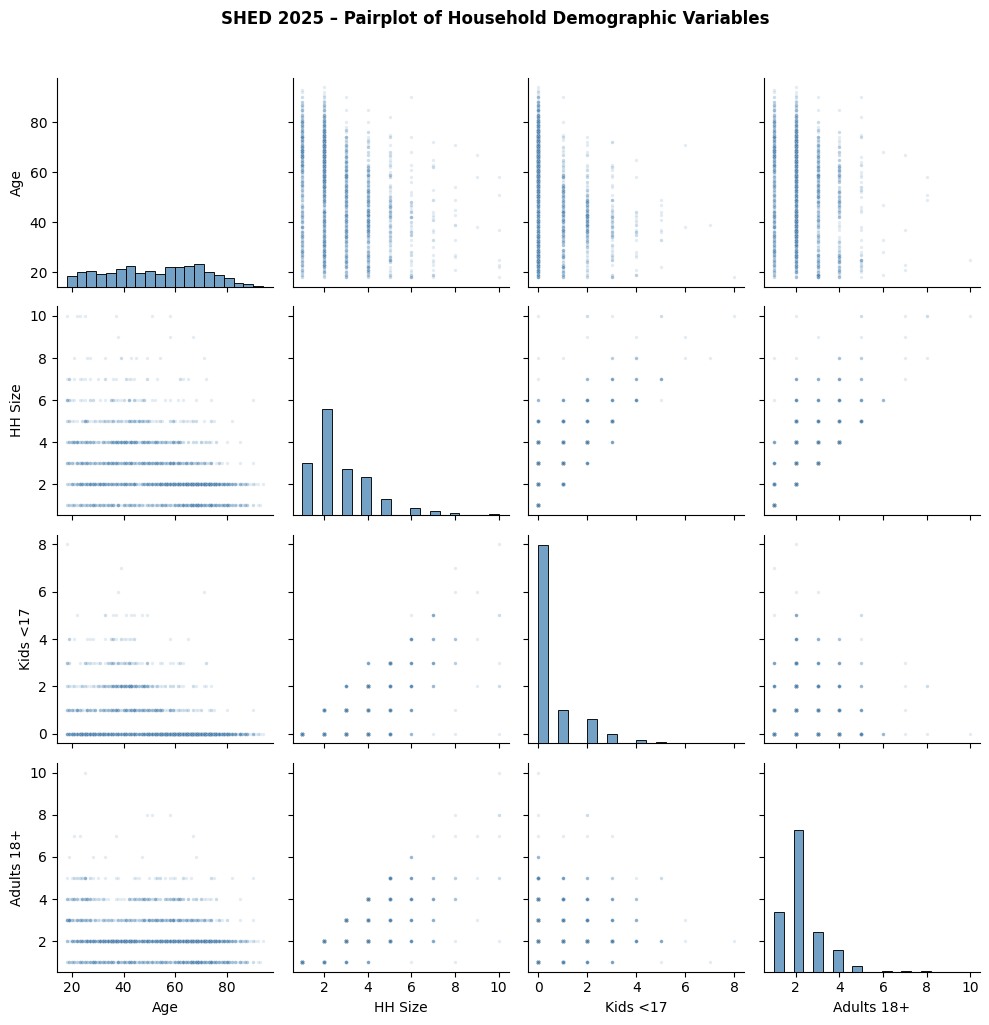

In [11]:
# Sample 2000 rows for plotting speed; random_state ensures reproducibility
pair_df = shed[['ppage', 'pphhsize', 'ppkid017', 'ppt18ov']].dropna().sample(2000, random_state=42)
pair_df.columns = ['Age', 'HH Size', 'Kids <17', 'Adults 18+']

g = sns.pairplot(
    pair_df,
    plot_kws={'alpha': 0.15, 's': 6, 'color': 'steelblue'},
    diag_kws={'color': 'steelblue', 'bins': 20}
)
g.fig.suptitle('SHED 2025 – Pairplot of Household Demographic Variables',
               y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Section 3 Conclusions – SHED Dataset

**Are the data what we expect? Are they usable?**
Yes. Published by the Federal Reserve Board with rigorous survey design and documentation. No unexpected values in the selected columns; all ranges are plausible.

**Correlations found:**
- `pphhsize` ↔ `ppt18ov` (≈ +0.85): **Very strong positive.** Larger households naturally contain more adults — these two variables are essentially measuring the same dimension and are **redundant** for modeling. Using both would cause multicollinearity.
- `pphhsize` ↔ `ppkid017` (≈ +0.62): **Moderate-strong positive.** Households with children are larger on average.
- `ppage` ↔ `ppkid017` (≈ −0.25): **Moderate negative.** Older respondents tend to have fewer children still living at home (empty-nester effect).
- `ppage` ↔ `pphhsize` (≈ −0.10): **Weak negative.** Older respondents slightly more likely to live alone.
- `pphhsize5` is a binned version of `pphhsize` — it adds no new information and is **fully redundant**.

**Outliers:**
Household sizes up to 12 exist in the data. These are rare but plausible for large families and are not data errors.

**Redundant variables:**
`pphhsize` and `ppt18ov` are strongly correlated and measure the same dimension from different angles. `pphhsize5` (5-category binned size) is fully derived from `pphhsize` — completely redundant.

**Line/time trend:**
The SHED dataset has a `field_month` and `field_day` column indicating when each respondent completed the survey, but there is no time-series component in the substantive variables — no trend analysis is applicable.

**Confounding variables:**
- The `ppage` – `ppkid017` relationship is confounded by **life stage**: middle-aged respondents (35–55) are most likely to have children at home, creating a non-linear U-shape that a simple Pearson r understates.
- Income (`ppinc7`) could confound `pphhsize` – `ppkid017`: family structure and household size differ significantly by income level.

# 4. Storytelling With Data Plot

Reproduce any graph of your choice in p. 86–98 of the *Storytelling With Data* book (the second half of Chapter 3: Clutter is your enemy!).

**Choice:** I reproduce the **before vs. after decluttering** comparison that is central to pp. 86–98. The chapter argues that removing gridlines, heavy borders, tick marks, data markers, and redundant labels dramatically improves clarity. The “after” version uses pre-attentive color to highlight the key series and states the insight in the title.

**Data:** Simulated quarterly conversion rates for two ad campaigns (matches the style of line chart examples in the chapter).

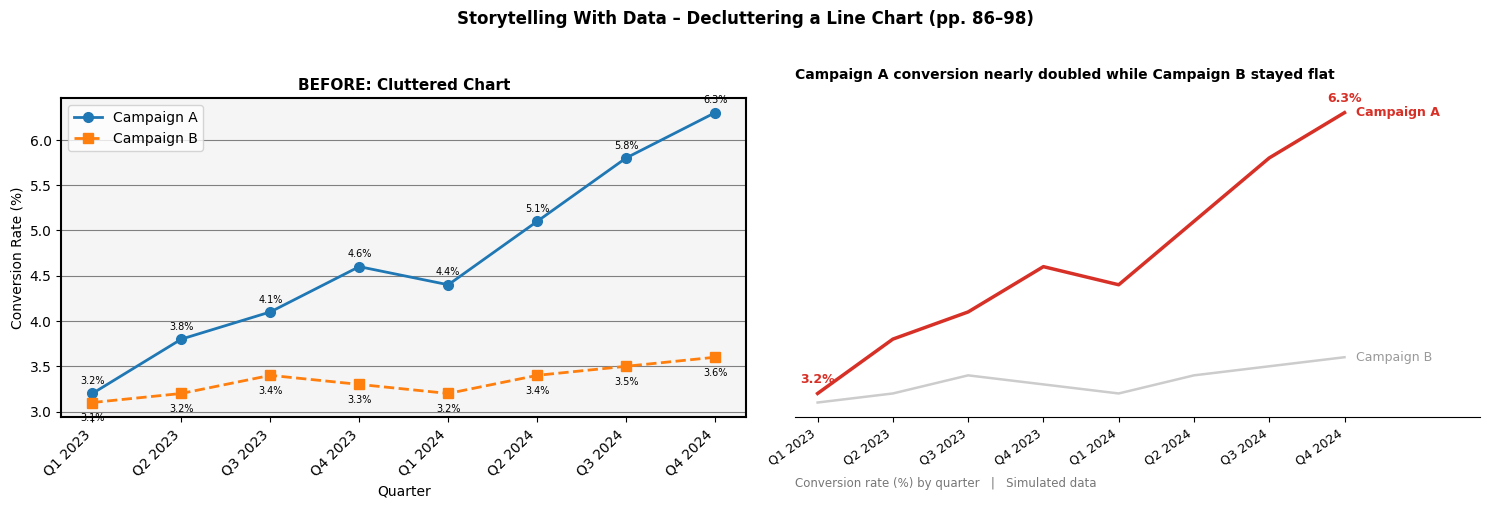

In [12]:
# Storytelling With Data pp. 86-98 (Ch. 3: Clutter is your enemy!)
# Reproduction: before/after pair — cluttered chart (left) vs. clean SWD version (right).
# Simulated data: quarterly website conversion rate for two marketing campaigns.

import matplotlib.pyplot as plt
import numpy as np

quarters   = ['Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023',
               'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024']
campaign_a = [3.2, 3.8, 4.1, 4.6, 4.4, 5.1, 5.8, 6.3]
campaign_b = [3.1, 3.2, 3.4, 3.3, 3.2, 3.4, 3.5, 3.6]
x          = np.arange(len(quarters))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ---- LEFT: BEFORE (cluttered) ----
ax1.plot(x, campaign_a, marker='o', color='#1f77b4', lw=2, markersize=7, label='Campaign A')
ax1.plot(x, campaign_b, marker='s', color='#ff7f0e', lw=2, linestyle='--', markersize=7, label='Campaign B')
ax1.set_xticks(x)
ax1.set_xticklabels(quarters, rotation=45, ha='right')
ax1.set_title('BEFORE: Cluttered Chart', fontsize=11, fontweight='bold')
ax1.set_ylabel('Conversion Rate (%)', fontsize=10)
ax1.set_xlabel('Quarter', fontsize=10)
ax1.legend(loc='upper left')
ax1.yaxis.grid(True, color='grey', linestyle='-', linewidth=0.8)
ax1.set_facecolor('#f5f5f5')
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
for xi, (ya, yb) in zip(x, zip(campaign_a, campaign_b)):
    ax1.annotate(f'{ya}%', (xi, ya), textcoords='offset points', xytext=(0, 7),
                 ha='center', fontsize=7)
    ax1.annotate(f'{yb}%', (xi, yb), textcoords='offset points', xytext=(0, -13),
                 ha='center', fontsize=7)

# ---- RIGHT: AFTER (SWD-style, decluttered) ----
# Campaign A highlighted (the insight: it grew 2x); Campaign B greyed out
ax2.plot(x, campaign_b, lw=1.8, color='#cccccc', label='Campaign B')
ax2.plot(x, campaign_a, lw=2.5, color='#d73027', label='Campaign A')  # accent color

# Direct end labels instead of legend
ax2.text(x[-1] + 0.15, campaign_a[-1], 'Campaign A', va='center',
         color='#d73027', fontsize=9, fontweight='bold')
ax2.text(x[-1] + 0.15, campaign_b[-1], 'Campaign B', va='center',
         color='#999999', fontsize=9)

# Only label start and end values to avoid clutter
for xi, val in [(0, campaign_a[0]), (len(x)-1, campaign_a[-1])]:
    ax2.annotate(f'{val}%', (xi, val), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9,
                 color='#d73027', fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(quarters, rotation=35, ha='right', fontsize=9)
ax2.set_xlim(-0.3, len(x) + 0.8)

# Remove all chart junk
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.yaxis.set_visible(False)
ax2.set_title('Campaign A conversion nearly doubled while Campaign B stayed flat',
              fontsize=10, fontweight='bold', loc='left', pad=14)
ax2.text(0, -0.22, 'Conversion rate (%) by quarter   |   Simulated data',
         transform=ax2.transAxes, fontsize=8.5, color='#777777')

fig.suptitle('Storytelling With Data – Decluttering a Line Chart (pp. 86–98)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()